<a href="https://colab.research.google.com/github/MarioRojasV/CNN_Models_Comparison_Bird_Classification/blob/main/src/mobilenetv2_model/MobileNetV2_Birds_COMPDES_2026_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report

print("GPU disponible:", tf.config.list_physical_devices('GPU'))

from google.colab import drive
drive.mount('/content/drive')

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
BASE_PATH = "/content/drive/MyDrive/Universidad/COMPDES2026_Aves_CR"
DATASET_PATH = BASE_PATH + "/Dataset"

TEST_REGULAR_PATH = DATASET_PATH + "/Testing_set/Regular_photos"
TEST_FLYING_PATH = DATASET_PATH + "/Testing_set/Flying_photos"

MODEL_PATH = BASE_PATH + "/Resultados_MobileNetV2/MobileNetV2_baseline.keras"
RESULTS_PATH = BASE_PATH + "/Resultados_MobileNetV2"
os.makedirs(RESULTS_PATH, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Etiquetas legibles para las figuras (mismas que en los otros dos modelos)
DISPLAY_LABELS = [
    "Quiscalus mexicanus\n(hembra)",
    "Turdus grayi"
]

In [3]:
model = tf.keras.models.load_model(MODEL_PATH)
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,672 (8.64 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 5,126 (20.03 KB)

In [4]:
def graficar_matriz_confusion(y_true, y_pred, labels, titulo, ruta_guardado, en_porcentaje=False):
    cm = confusion_matrix(y_true, y_pred)

    if en_porcentaje:
        datos = (cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]) * 100
        cmap, vmin, vmax = "Oranges", 0, 100
    else:
        datos = cm
        cmap, vmin, vmax = "Blues", None, None

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(datos, cmap=cmap, vmin=vmin, vmax=vmax)

    cbar = plt.colorbar(im)
    cbar.set_label("Porcentaje (%)" if en_porcentaje else "Cantidad de imágenes")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel("Clase predicha", fontsize=12, fontweight="bold")
    ax.set_ylabel("Clase real", fontsize=12, fontweight="bold")
    ax.set_title(titulo, fontsize=13, fontweight="bold")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            texto = f"{cm[i, j]}\n({datos[i, j]:.1f}%)" if en_porcentaje else str(cm[i, j])
            ax.text(j, i, texto, ha="center", va="center",
                    fontsize=12 if en_porcentaje else 14,
                    fontweight="bold", color="black")

    plt.tight_layout()
    plt.savefig(ruta_guardado, dpi=300, bbox_inches="tight")
    plt.show()
    return cm

In [5]:
test_regular_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_REGULAR_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pad_to_aspect_ratio=True
)

class_names = test_regular_ds.class_names
print("Clases (orden usado por el modelo):", class_names)

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
test_regular_ds = test_regular_ds.map(lambda x, y: (preprocess_input(x), y))

Found 80 files belonging to 2 classes.
Clases (orden usado por el modelo): ['Quiscalus_mexicanus_testing_photos', 'Turdus_grayi_testing_photos']


In [6]:
test_loss, test_accuracy = model.evaluate(test_regular_ds)
print("Test accuracy (MobileNetV2, Regular Photos):", test_accuracy)
print("Test loss (MobileNetV2, Regular Photos):", test_loss)

y_true_regular = []
y_pred_regular = []

for images, labels in test_regular_ds:
    predictions = model.predict(images, verbose=0)
    y_true_regular.extend(labels.numpy())
    y_pred_regular.extend(np.argmax(predictions, axis=1))

y_true_regular = np.array(y_true_regular)
y_pred_regular = np.array(y_pred_regular)

3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 6s/step - accuracy: 0.9625 - loss: 0.1502
Test accuracy (MobileNetV2, Regular Photos): 0.9624999761581421
Test loss (MobileNetV2, Regular Photos): 0.15018345415592194


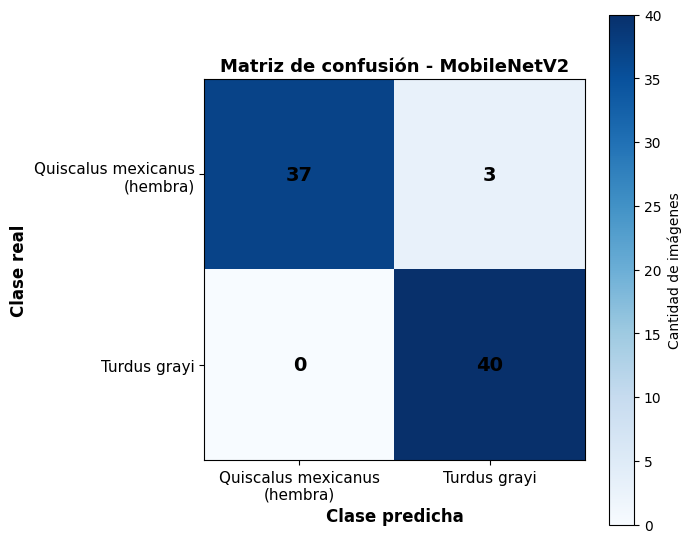

                                    precision    recall  f1-score   support

Quiscalus_mexicanus_testing_photos       1.00      0.93      0.96        40
       Turdus_grayi_testing_photos       0.93      1.00      0.96        40

                          accuracy                           0.96        80
                         macro avg       0.97      0.96      0.96        80
                      weighted avg       0.97      0.96      0.96        80



In [7]:
cm_regular = graficar_matriz_confusion(
    y_true_regular, y_pred_regular, DISPLAY_LABELS,
    "Matriz de confusión - MobileNetV2",
    RESULTS_PATH + "/Matriz_Confusion_MobileNetV2_Regular.png"
)

print(classification_report(y_true_regular, y_pred_regular, target_names=class_names))

In [8]:
test_flying_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_FLYING_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pad_to_aspect_ratio=True
)

test_flying_ds = test_flying_ds.map(lambda x, y: (preprocess_input(x), y))

Found 20 files belonging to 2 classes.


In [9]:
flying_loss, flying_accuracy = model.evaluate(test_flying_ds)
print("Test accuracy (MobileNetV2, Flying Photos):", flying_accuracy)
print("Test loss (MobileNetV2, Flying Photos):", flying_loss)

y_true_flying = []
y_pred_flying = []

for images, labels in test_flying_ds:
    predictions = model.predict(images, verbose=0)
    y_true_flying.extend(labels.numpy())
    y_pred_flying.extend(np.argmax(predictions, axis=1))

y_true_flying = np.array(y_true_flying)
y_pred_flying = np.array(y_pred_flying)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.7500 - loss: 0.5267
Test accuracy (MobileNetV2, Flying Photos): 0.75
Test loss (MobileNetV2, Flying Photos): 0.5267198085784912


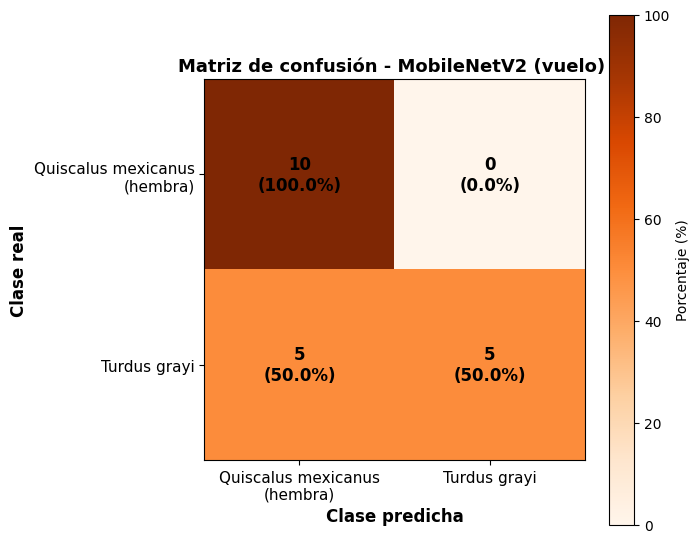

                                    precision    recall  f1-score   support

Quiscalus_mexicanus_testing_photos       0.67      1.00      0.80        10
       Turdus_grayi_testing_photos       1.00      0.50      0.67        10

                          accuracy                           0.75        20
                         macro avg       0.83      0.75      0.73        20
                      weighted avg       0.83      0.75      0.73        20



In [10]:
cm_flying = graficar_matriz_confusion(
    y_true_flying, y_pred_flying, DISPLAY_LABELS,
    "Matriz de confusión - MobileNetV2 (vuelo) ",
    RESULTS_PATH + "/Matriz_Confusion_MobileNetV2_Flying.png",
    en_porcentaje=True
)

print(classification_report(y_true_flying, y_pred_flying, target_names=class_names))

In [11]:
def analizar_confianza_por_categoria(dataset, model, class_names, titulo):
    """
    Para cada combinación (clase real, clase predicha), calcula la confianza
    promedio, mínima y máxima del modelo, y su contribución estimada a la pérdida.
    """
    y_true_list = []
    y_pred_list = []
    probs_list = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)  # Shape: (batch, 2)
        y_true_list.extend(labels.numpy())
        y_pred_list.extend(np.argmax(probs, axis=1))
        probs_list.extend(probs)

    y_true_arr = np.array(y_true_list)
    y_pred_arr = np.array(y_pred_list)
    probs_arr  = np.array(probs_list)

    # Confianza = probabilidad asignada a la clase predicha
    confianza = probs_arr[np.arange(len(y_pred_arr)), y_pred_arr]

    # Pérdida por imagen = -log(probabilidad de la clase REAL)
    prob_clase_real = probs_arr[np.arange(len(y_true_arr)), y_true_arr]
    perdida_por_imagen = -np.log(np.clip(prob_clase_real, 1e-7, 1.0))

    nombres_cortos = ["Q. mexicanus", "T. grayi"]

    print("=" * 65)
    print(f"ANÁLISIS DE CONFIANZA POR CATEGORÍA — {titulo}")
    print("=" * 65)

    for real in range(2):
        for predicha in range(2):
            mascara = (y_true_arr == real) & (y_pred_arr == predicha)
            n = int(mascara.sum())
            if n == 0:
                continue

            tipo = "✓ ACIERTO" if real == predicha else "✗ ERROR"
            conf = confianza[mascara]
            perdida = perdida_por_imagen[mascara]

            print(f"\n{tipo} | Real: {nombres_cortos[real]}"
                  f"  →  Predicha: {nombres_cortos[predicha]}")
            print(f"  Cantidad de imágenes : {n}")
            print(f"  Confianza promedio   : {conf.mean()*100:.2f}%")
            print(f"  Confianza mínima     : {conf.min()*100:.2f}%")
            print(f"  Confianza máxima     : {conf.max()*100:.2f}%")
            print(f"  Pérdida promedio     : {perdida.mean():.4f}")

    print(f"\n  Pérdida global promedio: {perdida_por_imagen.mean():.4f}")
    print("=" * 65)

In [12]:
# Regular_photos
# Recreamos el dataset para poder iterar de nuevo sobre él limpiamente
test_regular_analisis = tf.keras.utils.image_dataset_from_directory(
    TEST_REGULAR_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pad_to_aspect_ratio=True
)
test_regular_analisis = test_regular_analisis.map(
    lambda x, y: (preprocess_input(x), y)
)

analizar_confianza_por_categoria(
    test_regular_analisis, model, class_names,
    "MobileNetV2 — Fotos regulares"
)

# Flying_photos
test_flying_analisis = tf.keras.utils.image_dataset_from_directory(
    TEST_FLYING_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pad_to_aspect_ratio=True
)
test_flying_analisis = test_flying_analisis.map(
    lambda x, y: (preprocess_input(x), y)
)

analizar_confianza_por_categoria(
    test_flying_analisis, model, class_names,
    "MobileNetV2 — Fotografías en vuelo"
)

Found 80 files belonging to 2 classes.
ANÁLISIS DE CONFIANZA POR CATEGORÍA — MobileNetV2 — Fotos regulares

✓ ACIERTO | Real: Q. mexicanus  →  Predicha: Q. mexicanus
  Cantidad de imágenes : 37
  Confianza promedio   : 91.64%
  Confianza mínima     : 55.43%
  Confianza máxima     : 99.99%
  Pérdida promedio     : 0.0971

✗ ERROR | Real: Q. mexicanus  →  Predicha: T. grayi
  Cantidad de imágenes : 3
  Confianza promedio   : 74.21%
  Confianza mínima     : 58.12%
  Confianza máxima     : 86.11%
  Pérdida promedio     : 1.4591

✓ ACIERTO | Real: T. grayi  →  Predicha: T. grayi
  Cantidad de imágenes : 40
  Confianza promedio   : 90.97%
  Confianza mínima     : 64.48%
  Confianza máxima     : 99.81%
  Pérdida promedio     : 0.1011

  Pérdida global promedio: 0.1502
Found 20 files belonging to 2 classes.
ANÁLISIS DE CONFIANZA POR CATEGORÍA — MobileNetV2 — Fotografías en vuelo

✓ ACIERTO | Real: Q. mexicanus  →  Predicha: Q. mexicanus
  Cantidad de imágenes : 10
  Confianza promedio   : 95.0